In [2]:
import numpy as np
import matplotlib.pyplot as plt

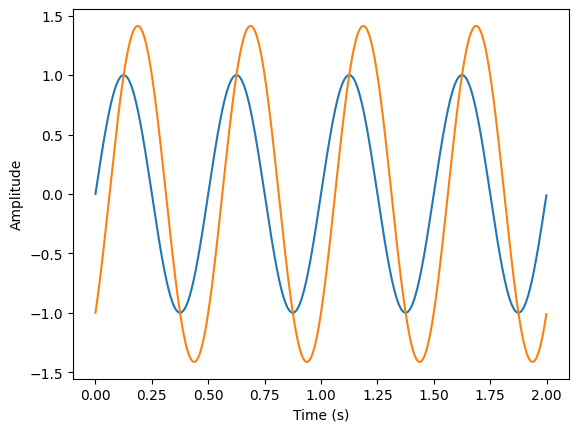

In [3]:
def sin(t: np.ndarray, f: float) -> np.ndarray:
    """Generate a sine wave signal."""
    return np.sin(2 * np.pi * f * t)


def frequency_amplitude(t: np.ndarray, y: np.ndarray, target_freq: float) -> float:
    """Calculate the peak frequency and its amplitude from the signal."""

    T = t[1] - t[0]  # Sampling period
    N = len(y)  # Number of samples
    sample_duration = t[-1] - t[0]

    # Perform FFT
    fft_values = np.fft.fft(y)
    freq = np.fft.fftfreq(N, T)

    # Calculate magnitude and amplitude spectrum
    magnitude = np.abs(fft_values)
    amplitude_spectrum = (sample_duration / N) * magnitude

    # Find peak frequency
    # Find the index of the frequency closest to target_freq
    idx = np.abs(freq - target_freq).argmin()
    amp = amplitude_spectrum[idx]

    return amp


def notch_filter(t: np.ndarray, y: np.ndarray, removed_freq: np.ndarray):
    return y - frequency_amplitude(t, y, removed_freq) * np.sin(2 * np.pi * removed_freq * t + np.pi/2)


Fs = 1000
T = 1/Fs

t = np.arange(0, 2, T)
y = sin(t, 2)
notched_y = notch_filter(t, y, 2)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.plot(t, y)
plt.plot(t, notched_y)
plt.show()

In [16]:
signal = 1.5 * sin(t, 40)

rms = np.sqrt(np.pow(signal, 2).mean())

rms

np.float64(1.0606601717798214)